# ED408 — Statistical Machine Learning II Lab
## Experiment 7: Logistic Regression vs SVM — accuracy, precision, recall, F1, ROC-AUC
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 7 — Logistic Regression vs SVM: accuracy, precision, recall, F1, ROC-AUC

Both models: standardised features, `class_weight="balanced"`. SVM = RBF kernel with probability estimates (trained on a stratified subsample for tractability; O(n²)–O(n³) kernel cost). We report the full metric table, ROC curves and confusion matrices — and discuss which metric a *boundary detector* should care about. Notably, the BSDS benchmark itself scores detectors by **boundary F1**, never accuracy.

In [2]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# helpers shared with Labs 1 and 4
def stratified_subsample(X, y, n, rng):
    idx = np.hstack([rng.choice(np.where(y==c)[0], int(n*(y==c).mean()), replace=False) for c in (0,1)])
    rng.shuffle(idx)
    return X[idx], y[idx]

mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-12
Zt, Ze = (X_tr - mu)/sd, (X_te - mu)/sd

           accuracy  precision  recall      F1  ROC-AUC
model                                                  
LogReg       0.7761     0.5649  0.6983  0.6246   0.8385
SVM (RBF)    0.7789     0.5673  0.7200  0.6346   0.8319


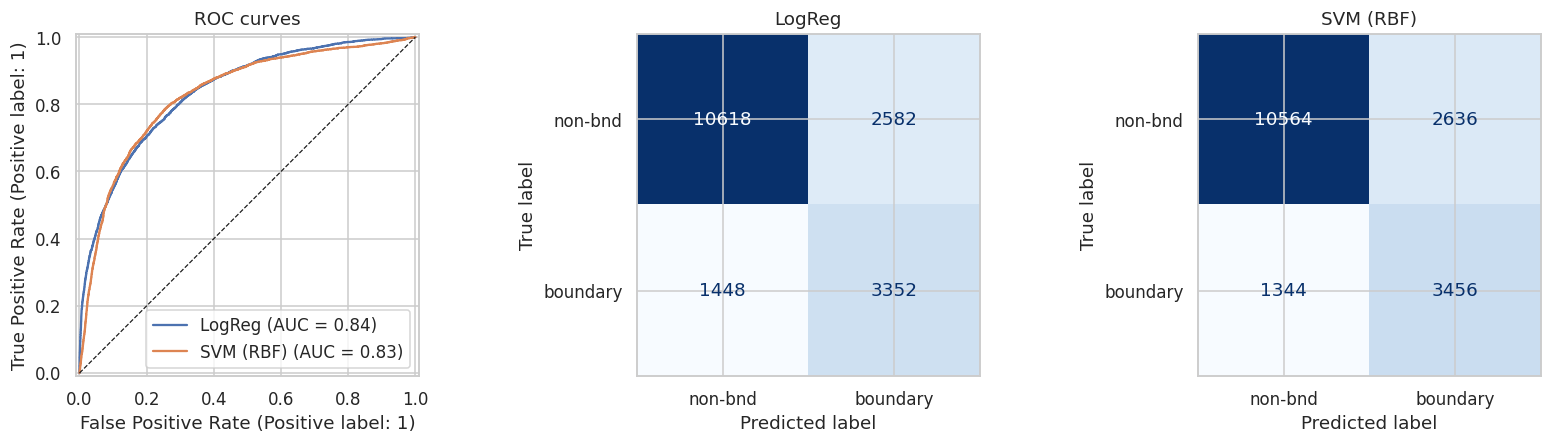

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, RocCurveDisplay,
                             ConfusionMatrixDisplay)

Xs, ys = stratified_subsample(Zt, y_tr, 8000, np.random.default_rng(7))

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced").fit(Zt, y_tr),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                     probability=True, random_state=0).fit(Xs, ys),
}

rows, probs = [], {}
for name, m in models.items():
    p = m.predict_proba(Ze)[:, 1]
    yhat = m.predict(Ze)
    probs[name] = p
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_te, yhat),
                 "precision": precision_score(y_te, yhat),
                 "recall": recall_score(y_te, yhat),
                 "F1": f1_score(y_te, yhat),
                 "ROC-AUC": roc_auc_score(y_te, p)})
table = pd.DataFrame(rows).set_index("model").round(4)
print(table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for name in models:
    RocCurveDisplay.from_predictions(y_te, probs[name], name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],"k--", lw=.8); axes[0].set_title("ROC curves")
for ax, (name, m) in zip(axes[1:], models.items()):
    ConfusionMatrixDisplay.from_predictions(y_te, m.predict(Ze), ax=ax,
        display_labels=["non-bnd","boundary"], colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Observations & discussion.**
- The RBF SVM can express genuinely nonlinear rules such as "high fine-scale gradient AND low large-scale texture", which a linear model cannot — the comparison shows how much that expressiveness is worth on this feature set.
- The BSDS community evaluates boundary detectors by **F1 between predicted and human boundaries**, never accuracy: with rare positives, a blank prediction scores high accuracy. Our metric discussion therefore matches how this dataset is actually benchmarked in the literature.
- The remaining errors are systematic, not random: texture edges (false positives) and low-contrast semantic boundaries (false negatives) — the exact gap that motivated learning-based detectors (Pb, gPb, and ultimately CNNs) on this benchmark.

### Cross-lab summary
| Lab | Model | Key takeaway on BSDS boundary detection |
|---|---|---|
| 1 | kNN (scratch) | scaling fixes the metric; local filter space is genuinely structured |
| 2 | Decision tree | rediscovers gradient thresholding; pruning removes texture-memorising leaves |
| 3 | Naive Bayes | log-transform repairs likelihoods; NB vs QDA prices the independence assumption |
| 4 | LogReg (scratch) | matches sklearn; coefficients read as an interpretable edge-vs-texture filter |
| 5 | PCA / t-SNE | filter banks are redundant (few PCs); classes overlap where humans disagree |
| 6 | Outliers | extreme filter responses are signal, not noise — treatment judged downstream |
| 7 | LR vs SVM | F1 is the community's metric for a reason; errors are texture vs low-contrast |
